In [83]:
# Standard Library
import re
import json
import os
import subprocess
import sys
import zipfile
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# Third-Party: Data Manipulation & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

# Third-Party: Kaggle API
from kaggle.api.kaggle_api_extended import KaggleApi

# Jupyter Display Configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
sns.set_theme(style="whitegrid", palette="muted")

In [84]:
def verify_kaggle_authentication() -> None:
    """Initializes the Kaggle API client and verifies authentication."""
    api = KaggleApi()
    api.authenticate()
    print("Kaggle API authenticated successfully. Ready for data ingestion.")

verify_kaggle_authentication()

Kaggle API authenticated successfully. Ready for data ingestion.


# Supplementary paths

In [85]:
supplementary_path = Path("data/supplementary")
if not supplementary_path.exists():
    supplementary_path.mkdir(parents=True, exist_ok=True)

# Dataset: Titanic

In [86]:
from pathlib import Path
from zipfile import ZipFile
from kaggle.api.kaggle_api_extended import KaggleApi


def download_competition_dataset(api: KaggleApi, competition: str, destination: Path) -> None:
    """Downloads the competition dataset to the specified directory."""
    destination.mkdir(parents=True, exist_ok=True)
    api.competition_download_files(competition=competition, path=str(destination))


def extract_zip_files(directory: Path) -> None:
    """Extracts and removes all zip files in the specified directory."""
    for zip_path in directory.glob("*.zip"):
        with ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(directory)
        zip_path.unlink()


def ingest_titanic_dataset(root_directory: Path) -> Path:
    """Authenticates, downloads, and extracts the Titanic dataset."""
    api = KaggleApi()
    api.authenticate()

    data_directory = root_directory / "data" / "titanic"
    download_competition_dataset(api=api, competition="titanic", destination=data_directory)
    extract_zip_files(directory=data_directory)

    return data_directory

titanic_data_path = ingest_titanic_dataset(root_directory=Path.cwd())
print(f"Dataset successfully prepared at: {titanic_data_path.resolve()}")

Dataset successfully prepared at: /home/nk/code/kaggle/titanic/data/titanic


# Example submission

In [87]:
results_file_path_example = Path("data/titanic/gender_submission.csv")
assert results_file_path_example.exists(), f"The file {results_file_path_example} does not exist."

def submit_to_kaggle(file_path: Path, competition: str, message: str) -> None:
    api = KaggleApi()
    api.authenticate()
    api.competition_submit(file_name=str(file_path), message=message, competition=competition)

# submit_to_kaggle(file_path=results_file_path_example, competition="titanic", message="Example submission")

# Dataset review

In [88]:
train_data_path = titanic_data_path / "train.csv"
assert train_data_path.exists(), f"The file {train_data_path} does not exist."

train_df: pd.DataFrame = pd.read_csv(train_data_path)
train_df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
20,21,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0000,NaN,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S


# Exploratory Data Analysis (EDA)
## Pandas Profiling / ydata-profiling: Automated EDA reports.

In [89]:
from data_profiling import ProfileReport

In [90]:
profile = ProfileReport(train_df, title="Titanic EDA Report", explorative=True)
profile.to_file(supplementary_path / "titanic_eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 164.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Hypothesis-Driven Visual EDA

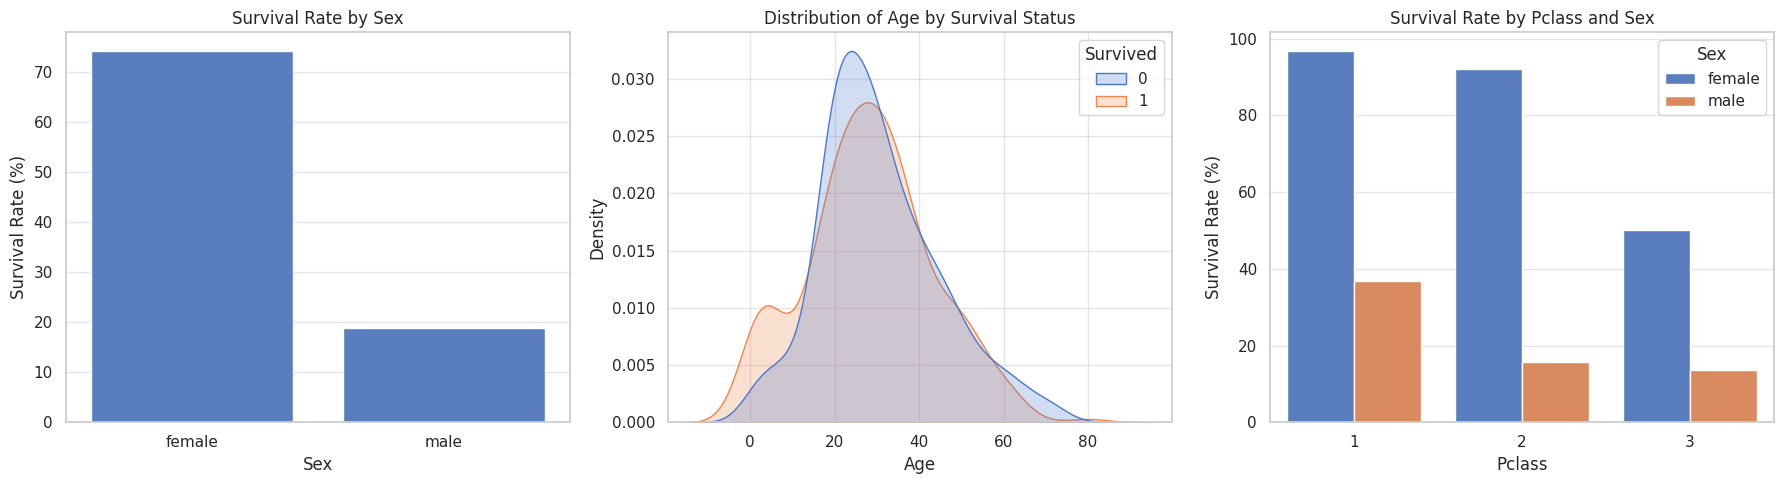

In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from typing import List

def calculate_survival_rates(df: pd.DataFrame, group_columns: List[str]) -> pd.DataFrame:
    return df.groupby(group_columns)["Survived"].mean().mul(100).reset_index()

def plot_three_column_eda(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sex_survival = calculate_survival_rates(df, ["Sex"])
    sns.barplot(data=sex_survival, x="Sex", y="Survived", ax=axes[0])
    axes[0].set_ylabel("Survival Rate (%)")
    axes[0].set_title("Survival Rate by Sex")

    sns.kdeplot(data=df, x="Age", hue="Survived", fill=True, common_norm=False, ax=axes[1])
    axes[1].set_title("Distribution of Age by Survival Status")

    pclass_sex_survival = calculate_survival_rates(df, ["Pclass", "Sex"])
    sns.barplot(data=pclass_sex_survival, x="Pclass", y="Survived", hue="Sex", ax=axes[2])
    axes[2].set_ylabel("Survival Rate (%)")
    axes[2].set_title("Survival Rate by Pclass and Sex")

    plt.tight_layout()
    plt.show()


data_dir = Path("./data/titanic")
plot_three_column_eda(train_df)

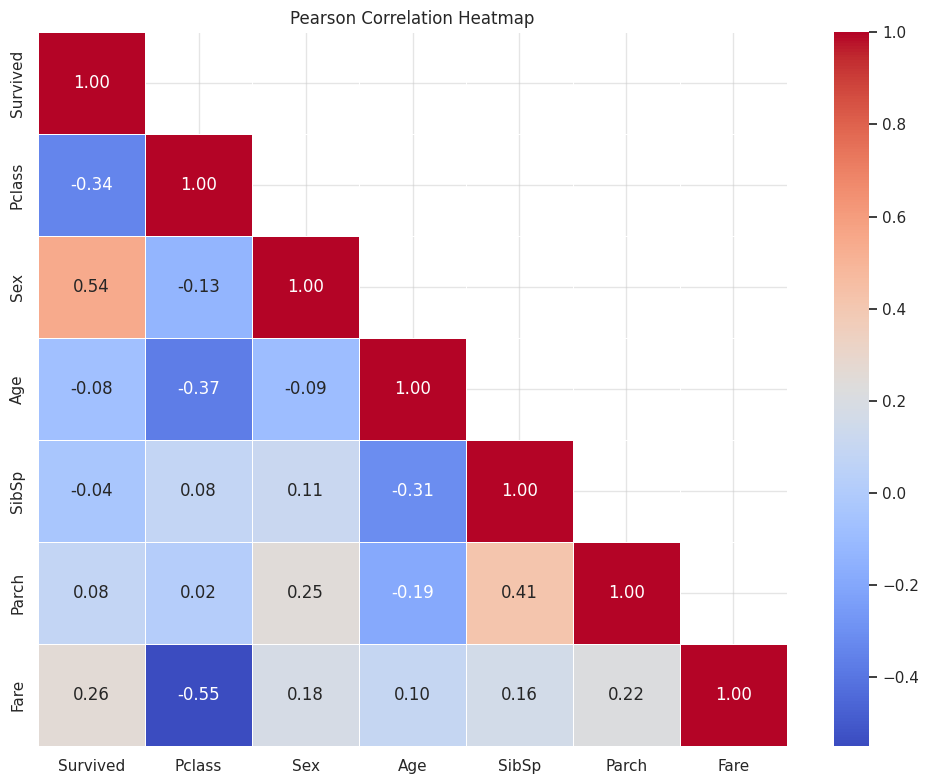

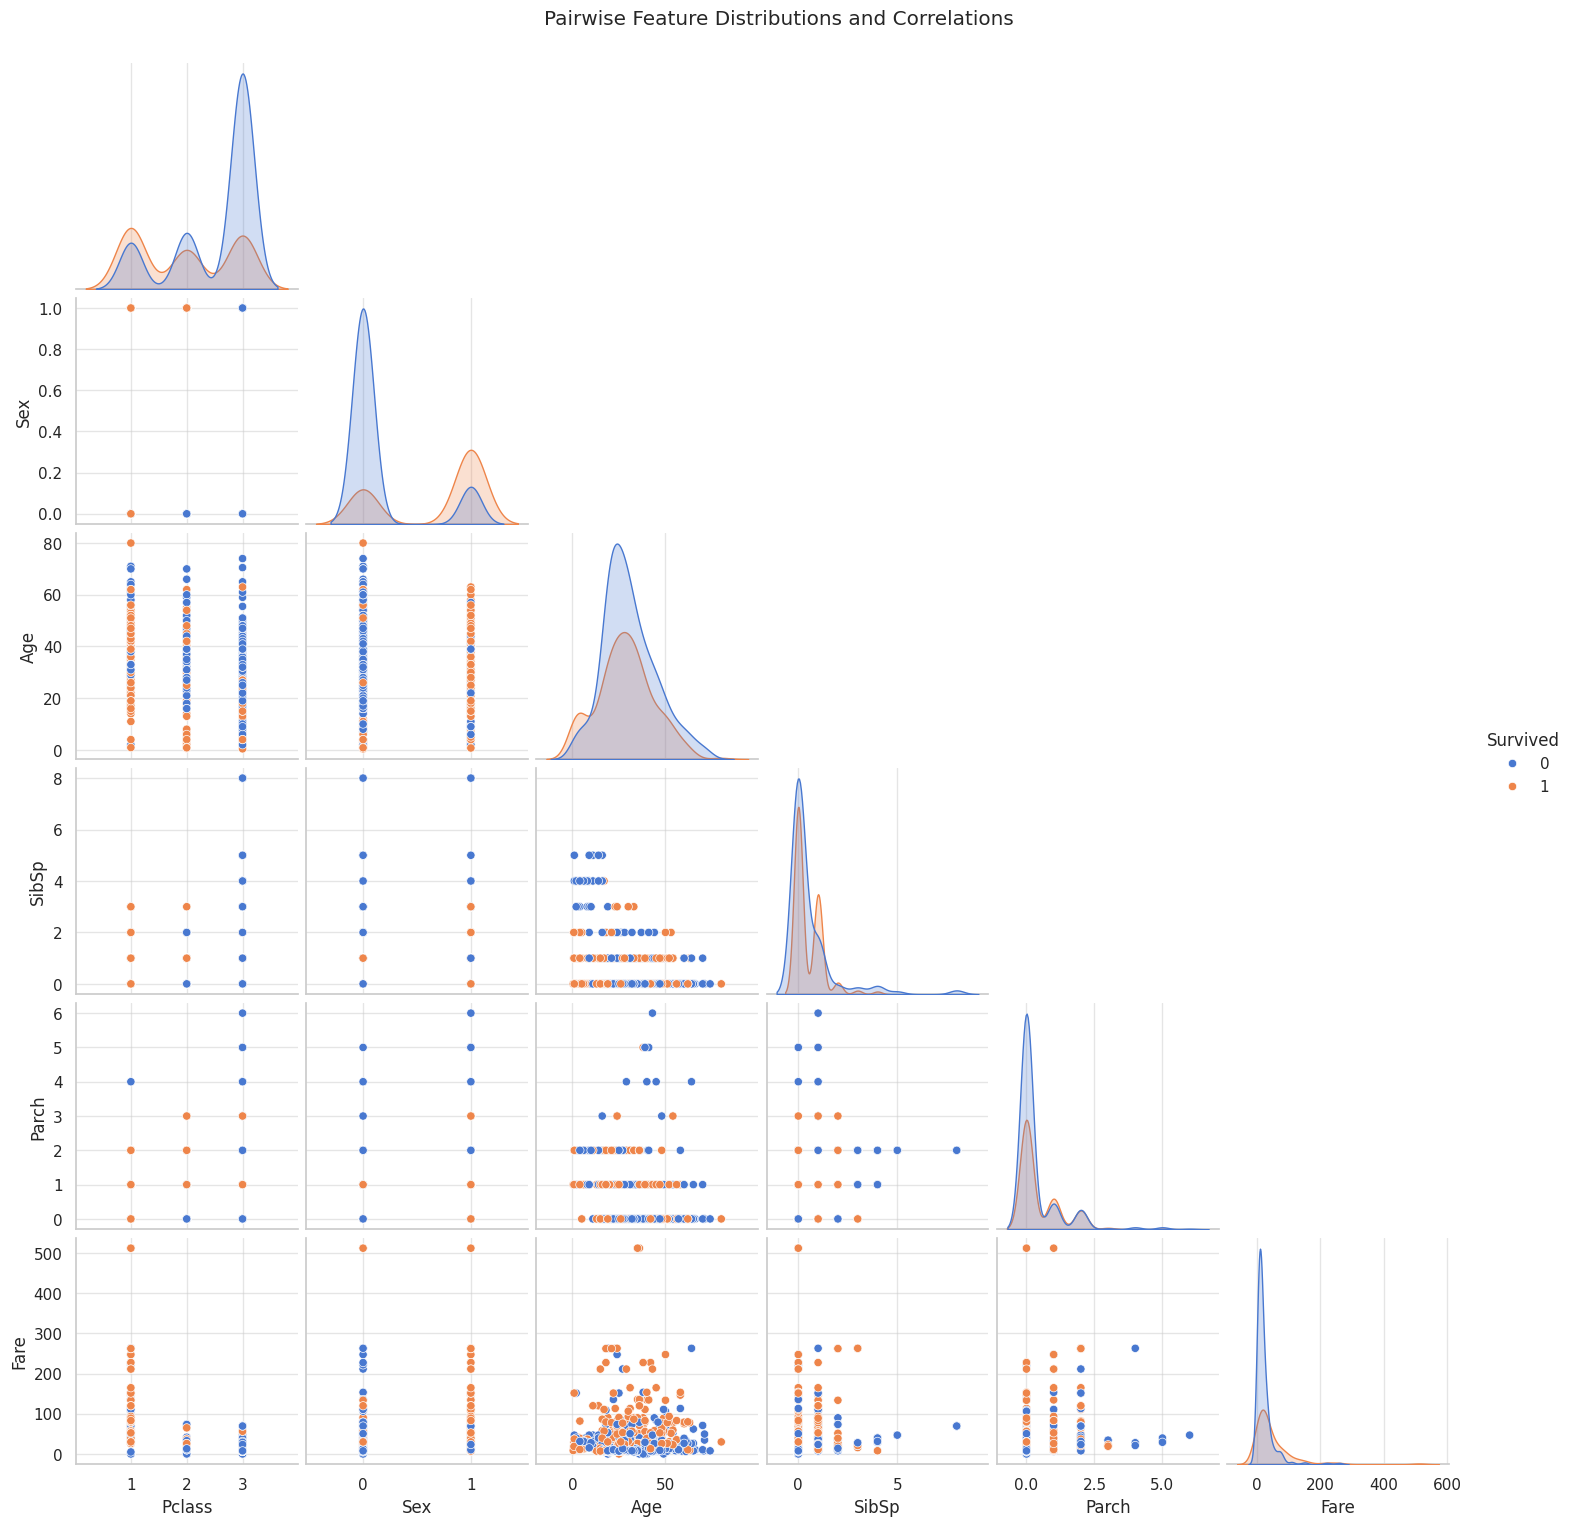

In [92]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from typing import List

def prepare_correlation_data(df: pd.DataFrame) -> pd.DataFrame:
    df_encoded = df.copy()
    df_encoded["Sex"] = df_encoded["Sex"].map({"male": 0, "female": 1})
    numeric_columns: List[str] = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
    return df_encoded[numeric_columns]

def render_correlation_heatmap(df: pd.DataFrame) -> None:
    plt.figure(figsize=(10, 8))
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

def render_pairwise_relationships(df: pd.DataFrame, target: str) -> None:
    sns.pairplot(df, hue=target, corner=True, diag_kind="kde")
    plt.suptitle("Pairwise Feature Distributions and Correlations", y=1.02)
    plt.show()

correlation_df = prepare_correlation_data(train_df)
render_correlation_heatmap(correlation_df)
render_pairwise_relationships(correlation_df, "Survived")

In [93]:
from scipy import stats

In [94]:
def compute_chi_square(df: pd.DataFrame, feature: str, target: str) -> Tuple[float, float]:
    contingency_table = pd.crosstab(df[feature], df[target])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency_table)
    return chi2, p_value

def compute_point_biserial(df: pd.DataFrame, feature: str, target: str) -> Tuple[float, float]:
    clean_df = df[[feature, target]].dropna()
    r_pb, p_value = stats.pointbiserialr(clean_df[target], clean_df[feature])
    return r_pb, p_value

def evaluate_categorical_features(df: pd.DataFrame, features: List[str], target: str) -> Dict[str, Dict[str, float]]:
    results = {}
    for feature in features:
        stat, p_val = compute_chi_square(df, feature, target)
        results[feature] = {"statistic": stat, "p_value": p_val}
    return results

def evaluate_continuous_features(df: pd.DataFrame, features: List[str], target: str) -> Dict[str, Dict[str, float]]:
    results = {}
    for feature in features:
        stat, p_val = compute_point_biserial(df, feature, target)
        results[feature] = {"statistic": stat, "p_value": p_val}
    return results

def format_statistical_results(results: Dict[str, Dict[str, float]], test_name: str) -> pd.DataFrame:
    df_results = pd.DataFrame.from_dict(results, orient="index").reset_index()
    df_results.rename(columns={"index": "Feature"}, inplace=True)
    df_results["Test"] = test_name
    return df_results

categorical_features = ["Pclass", "Sex", "Embarked"]
continuous_features = ["Age", "SibSp", "Parch", "Fare"]

categorical_results = evaluate_categorical_features(train_df, categorical_features, "Survived")
continuous_results = evaluate_continuous_features(train_df, continuous_features, "Survived")

categorical_df = format_statistical_results(categorical_results, "Chi-Square")
continuous_df = format_statistical_results(continuous_results, "Point-Biserial")

print("--- Categorical Features (Chi-Square Test) ---")
print(categorical_df)
print("\n--- Continuous/Discrete Features (Point-Biserial Test) ---")
print(continuous_df)

--- Categorical Features (Chi-Square Test) ---
    Feature   statistic       p_value        Test
0    Pclass  102.888989  4.549252e-23  Chi-Square
1       Sex  260.717020  1.197357e-58  Chi-Square
2  Embarked   26.489150  1.769922e-06  Chi-Square

--- Continuous/Discrete Features (Point-Biserial Test) ---
  Feature  statistic       p_value            Test
0     Age  -0.077221  3.912465e-02  Point-Biserial
1   SibSp  -0.035322  2.922439e-01  Point-Biserial
2   Parch   0.081629  1.479925e-02  Point-Biserial
3    Fare   0.257307  6.120189e-15  Point-Biserial


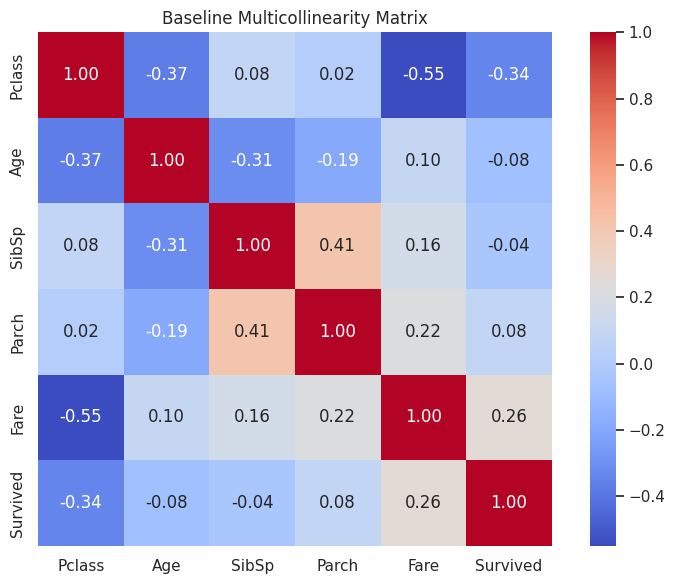

In [95]:
def compute_pearson_correlation(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    return df[columns].corr(method="pearson")

def render_multicollinearity_heatmap(corr_matrix: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Baseline Multicollinearity Matrix")
    plt.tight_layout()
    plt.show()

baseline_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "Survived"]
correlation_matrix = compute_pearson_correlation(train_df, baseline_features)
render_multicollinearity_heatmap(correlation_matrix)

## Preprocessing of data

In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

# Base model | XGBoost

In [97]:
from xgboost import XGBClassifier

In [98]:
def construct_preprocessor() -> ColumnTransformer:
    numeric_features = ["Age", "SibSp", "Parch", "Fare"]
    numeric_transformer = SimpleImputer(strategy="median")

    categorical_features = ["Sex", "Embarked", "Pclass"]
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

def construct_xgboost_baseline(preprocessor: ColumnTransformer) -> Pipeline:
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=50,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            eval_metric="logloss"
        ))
    ])

def evaluate_cross_validation(
    model: Pipeline,
    features: pd.DataFrame,
    target: pd.Series,
    n_splits: int
) -> Tuple[float, float]:
    cv_strategy = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_val_score(model, features, target, cv=cv_strategy, scoring="accuracy")
    return float(np.mean(scores)), float(np.std(scores))

In [99]:
feature_columns = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target_column = "Survived"

X_features = train_df[feature_columns]
y_target = train_df[target_column]

xgboost_baseline = construct_xgboost_baseline(construct_preprocessor())

In [100]:
mean_accuracy, std_accuracy = evaluate_cross_validation(xgboost_baseline, X_features, y_target, 5)
print(f"XGBoost Baseline Stratified 5-Fold CV Accuracy: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")

XGBoost Baseline Stratified 5-Fold CV Accuracy: 0.8339 (+/- 0.0219)


# Feature Engineering

In [101]:
def extract_title(name: str) -> str:
    match = re.search(r" ([A-Za-z]+)\.", name)
    if match:
        title = match.group(1)
        if title in ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]:
            return "Rare"
        if title in ["Mlle", "Miss"]:
            return "Miss"
        if title in ["Mrs", "Mme"]:
            return "Mrs"
        return title
    return "Unknown"

def extract_deck(cabin: str) -> str:
    if pd.isna(cabin):
        return "Missing"
    return str(cabin)[0]

def engineer_base_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Title"] = df["Name"].apply(extract_title)
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    df["HasCabin"] = df["Cabin"].notna().astype(int)
    df["Deck"] = df["Cabin"].apply(extract_deck)
    return df

def engineer_recommended_features(df: pd.DataFrame) -> pd.DataFrame:
    df = engineer_base_features(df)
    df["Log_Fare"] = np.log1p(df["Fare"])
    df["Is_Father"] = ((df["Sex"] == "male") & (df["Age"] > 18) & (df["Parch"] > 0)).astype(int)
    df["Fare_Per_Person"] = df["Fare"] / df["FamilySize"]
    return df

def engineer_binned_fare_features(df: pd.DataFrame) -> pd.DataFrame:
    df = engineer_base_features(df)
    df["Fare_Bin"] = pd.qcut(df["Fare"], q=5, labels=["Very_Low", "Low", "Medium", "High", "Very_High"], duplicates="drop")
    return df

def construct_recommended_preprocessor() -> ColumnTransformer:
    numeric_features = ["Age", "Log_Fare", "FamilySize", "HasCabin", "Fare_Per_Person"]
    numeric_transformer = SimpleImputer(strategy="median")

    categorical_features = ["Sex", "Embarked", "Pclass", "Title", "IsAlone", "Deck", "Is_Father"]
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

def construct_binned_fare_preprocessor() -> ColumnTransformer:
    numeric_features = ["Age", "FamilySize", "HasCabin"]
    numeric_transformer = SimpleImputer(strategy="median")

    categorical_features = ["Sex", "Embarked", "Pclass", "Title", "IsAlone", "Deck", "Fare_Bin"]
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

In [102]:
recommended_data = engineer_recommended_features(train_df)
recommended_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Title", "FamilySize", "IsAlone", "HasCabin", "Deck", "Log_Fare", "Is_Father", "Fare_Per_Person"]
recommended_pipeline = construct_xgboost_baseline(construct_recommended_preprocessor())
rec_mean, rec_std = evaluate_cross_validation(recommended_pipeline, recommended_data[recommended_features], y_target, 5)
print(f"Recommended Pipeline CV Accuracy: {rec_mean:.4f} (+/- {rec_std:.4f})")

binned_data = engineer_binned_fare_features(train_df)
binned_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Title", "FamilySize", "IsAlone", "HasCabin", "Deck", "Fare_Bin"]
binned_pipeline = construct_xgboost_baseline(construct_binned_fare_preprocessor())
bin_mean, bin_std = evaluate_cross_validation(binned_pipeline, binned_data[binned_features], y_target, 5)
print(f"Binned Fare Pipeline CV Accuracy: {bin_mean:.4f} (+/- {bin_std:.4f})")

Recommended Pipeline CV Accuracy: 0.8350 (+/- 0.0171)
Binned Fare Pipeline CV Accuracy: 0.8384 (+/- 0.0201)


In [103]:
from sklearn.base import BaseEstimator, TransformerMixin


class FrequencyEncoder(BaseEstimator, TransformerMixin):

    def __init__(self, columns: List[str]):
        self.columns = columns
        self.encodings_: Dict[str, Dict[Any, int]] = {}

    def fit(self, X: pd.DataFrame, y: pd.Series = None) -> "FrequencyEncoder":
        # Calculate frequencies strictly on the training fold
        self.encodings_ = {col: X[col].value_counts().to_dict() for col in self.columns}
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_transformed = X.copy()
        for col in self.columns:
            freq_col_name = f"{col}_Freq"
            # Map frequencies. Unseen categories in the validation fold default to 1.
            X_transformed[freq_col_name] = (
                X_transformed[col]
                .map(self.encodings_[col])
                .fillna(1)
                .astype(int)
            )
        return X_transformed

In [104]:
def construct_preprocessor_v4() -> Pipeline:
    # 1. Frequency Encoder
    freq_encoder = FrequencyEncoder(columns=["Ticket", "Cabin"])

    # 2. Standard Preprocessor
    # Note: Ticket_Freq and Cabin_Freq are added to numeric_features
    numeric_features = ["Age", "Fare", "FamilySize", "HasCabin", "Ticket_Freq", "Cabin_Freq"]
    numeric_transformer = SimpleImputer(strategy="median")

    categorical_features = ["Sex", "Embarked", "Pclass", "Title", "IsAlone", "Deck"]
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    # 3. Chain them together
    return Pipeline(steps=[
        ("freq_encoder", freq_encoder),
        ("preprocessor", preprocessor)
    ])

In [105]:
feature_columns = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked",
    "Title", "FamilySize", "IsAlone", "HasCabin", "Deck", "Ticket", "Cabin"
]
train_df = engineer_base_features(train_df)

X_features = train_df[feature_columns]
y_target = train_df[target_column]

preprocessor_pipeline = construct_preprocessor_v4()
xgboost_pipeline = construct_xgboost_baseline(preprocessor_pipeline)

mean_accuracy, std_accuracy = evaluate_cross_validation(xgboost_pipeline, X_features, y_target, 5)
print(f"Frequency Encoded XGBoost Stratified 5-Fold CV Accuracy: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")

Frequency Encoded XGBoost Stratified 5-Fold CV Accuracy: 0.8406 (+/- 0.0265)


In [106]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,HasCabin,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,0,Missing
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,1,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,0,Missing
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,1,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,0,Missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rare,1,1,0,Missing
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,1,1,1,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss,4,0,0,Missing
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,1,1,1,C


# Ensemble approach

In [107]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from typing import Dict, Any, Tuple

def construct_ensemble_preprocessor() -> Pipeline:
    """
    Constructs a preprocessor that includes StandardScaler for numeric features,
    which is mathematically mandatory for the SVM component of the ensemble.
    """
    freq_encoder = FrequencyEncoder(columns=["Ticket", "Cabin"])

    numeric_features = ["Age", "Fare", "FamilySize", "HasCabin", "Ticket_Freq", "Cabin_Freq"]
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_features = ["Sex", "Embarked", "Pclass", "Title", "IsAlone", "Deck"]
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    return Pipeline(steps=[
        ("freq_encoder", freq_encoder),
        ("preprocessor", preprocessor)
    ])

from sklearn.calibration import CalibratedClassifierCV

def construct_ensemble_pipeline(
    xgb_params: Dict[str, Any],
    preprocessor: Pipeline
) -> Pipeline:
    """
    Constructs a Soft Voting Ensemble pipeline with a properly configured SVM.
    Replaces deprecated SVC(probability=True) with CalibratedClassifierCV.
    """
    xgb_model = XGBClassifier(**xgb_params, random_state=42, eval_metric="logloss")

    rf_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=5,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )

    base_svm = SVC(
        kernel='rbf',
        C=2.0,
        gamma='scale',
        random_state=42
    )
    svm_model = CalibratedClassifierCV(estimator=base_svm, ensemble=False)

    ensemble = VotingClassifier(
        estimators=[
            ('xgb', xgb_model),
            ('rf', rf_model),
            ('svm', svm_model)
        ],
        voting='soft'
    )

    return Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("classifier", ensemble)
    ])

# --- Execution Block ---
data_directory = Path("./data/titanic")
train_df = pd.read_csv(data_directory / "train.csv")
train_df = engineer_base_features(train_df)

feature_columns = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked",
    "Title", "FamilySize", "IsAlone", "HasCabin", "Deck", "Ticket", "Cabin"
]

X_features = train_df[feature_columns]
y_target = train_df["Survived"]

baseline_xgb_params = {
    "n_estimators": 200,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.1
}

ensemble_preprocessor = construct_ensemble_preprocessor()
ensemble_pipeline = construct_ensemble_pipeline(baseline_xgb_params, ensemble_preprocessor)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(ensemble_pipeline, X_features, y_target, cv=cv_strategy, scoring="accuracy")
mean_accuracy = float(np.mean(scores))
std_accuracy = float(np.std(scores))

print(f"Ensemble Pipeline Stratified 5-Fold CV Accuracy: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")

Ensemble Pipeline Stratified 5-Fold CV Accuracy: 0.8316 (+/- 0.0096)


In [108]:
best_xgb_params = dict(n_estimators=50, max_depth=5, learning_rate=0.1)

base_preprocessor = construct_preprocessor_v4()
ensemble_pipeline = construct_ensemble_pipeline(best_xgb_params, base_preprocessor)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(ensemble_pipeline, X_features, y_target, cv=cv_strategy, scoring="accuracy")

print(f"Ensemble Stratified 5-Fold CV Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

Ensemble Stratified 5-Fold CV Accuracy: 0.8294 (+/- 0.0347)


In [109]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from typing import Dict, Any

def construct_tree_ensemble_pipeline(
    xgb_params: Dict[str, Any],
    preprocessor: Pipeline
) -> Pipeline:
    """
    Constructs a Tree-Only Soft Voting Ensemble.
    Replaces the SVM with diverse Random Forest configurations to ensure
    all base estimators are optimized for tabular data.
    """
    # 1. XGBoost (Will use Optuna's best parameters)
    xgb_model = XGBClassifier(**xgb_params, random_state=42, eval_metric="logloss")

    # 2. Random Forest (Shallow: High bias, low variance)
    rf_model_shallow = RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )

    # 3. Random Forest (Deep: Low bias, high variance)
    rf_model_deep = RandomForestClassifier(
        n_estimators=300,
        max_depth=7,
        min_samples_split=2,
        random_state=43,
        n_jobs=-1
    )

    # 4. Soft Voting Classifier
    ensemble = VotingClassifier(
        estimators=[
            ('xgb', xgb_model),
            ('rf_shallow', rf_model_shallow),
            ('rf_deep', rf_model_deep)
        ],
        voting='soft'
    )

    return Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("classifier", ensemble)
    ])

pipe = construct_tree_ensemble_pipeline(best_xgb_params, base_preprocessor)

mean_accuracy, std_accuracy = evaluate_cross_validation(pipe, X_features, y_target, 5)
print(f"Tree-Only Ensemble Stratified 5-Fold CV Accuracy: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")

Tree-Only Ensemble Stratified 5-Fold CV Accuracy: 0.8294 (+/- 0.0229)


# Full train

In [110]:
binned_data = engineer_binned_fare_features(train_df)
binned_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Title", "FamilySize", "IsAlone", "HasCabin", "Deck", "Fare_Bin"]

binned_pipeline = construct_xgboost_baseline(construct_binned_fare_preprocessor())

bin_mean, bin_std = evaluate_cross_validation(binned_pipeline, binned_data[binned_features], y_target, 5)
print(f"Binned Fare Pipeline CV Accuracy: {bin_mean:.4f} (+/- {bin_std:.4f})")

Binned Fare Pipeline CV Accuracy: 0.8384 (+/- 0.0201)


In [118]:
test_df = pd.read_csv(titanic_data_path / "test.csv")

In [124]:
from sklearn.metrics import accuracy_score

def fit_and_predict_all(
    pipeline: Pipeline,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_columns: List[str],
    target_column: str
) -> Dict[str, Any]:
    """
    Fits the pipeline on the training data and generates predictions for both
    the training and test sets. Calculates and returns the training accuracy.
    """
    test_df = test_df.copy()
    if test_df["Fare"].isnull().any():
        test_df["Fare"] = test_df["Fare"].fillna(train_df["Fare"].median())

    train_engineered = engineer_binned_fare_features(train_df)
    test_engineered = engineer_binned_fare_features(test_df)

    X_train = train_engineered[feature_columns]
    y_train = train_engineered[target_column]
    X_test = test_engineered[feature_columns]

    pipeline.fit(X_train, y_train)

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)
    train_accuracy = accuracy_score(y_train, train_predictions)

    return {
        "train_predictions": pd.Series(train_predictions, name="Survived"),
        "test_predictions": pd.Series(test_predictions, name="Survived"),
        "train_accuracy": train_accuracy
    }

In [127]:
results = fit_and_predict_all(
    pipeline=binned_pipeline,
    train_df=train_df,
    test_df=test_df,
    feature_columns=binned_features,
    target_column="Survived"
)

print(f"Training Accuracy: {results['train_accuracy']:.4f}")

Training Accuracy: 0.8855


# Param opt

## CPU

In [128]:
import numpy as np
import optuna
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from typing import Callable

def create_binned_fare_objective(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5
) -> Callable[[optuna.Trial], float]:
    def objective(trial: optuna.Trial) -> float:
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "random_state": 42,
            "eval_metric": "logloss",
        }

        pipeline = Pipeline(steps=[
            ("preprocessor", construct_binned_fare_preprocessor()),
            ("classifier", XGBClassifier(**params))
        ])

        cv_strategy = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = cross_val_score(pipeline, X, y, cv=cv_strategy, scoring="accuracy")
        return float(np.mean(scores))

    return objective

def run_optuna_optimization(
    objective_func: Callable[[optuna.Trial], float],
    n_trials: int = 100
) -> optuna.Study:
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_func, n_trials=n_trials, show_progress_bar=False)
    return study

data_directory = Path("./data/titanic")
train_df = pd.read_csv(data_directory / "train.csv")
train_engineered = engineer_binned_fare_features(train_df)

feature_columns = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked",
    "Title", "FamilySize", "IsAlone", "HasCabin", "Deck", "Fare_Bin"
]

X_features = train_engineered[feature_columns]
y_target = train_engineered["Survived"]

objective_func = create_binned_fare_objective(X_features, y_target)
study = run_optuna_optimization(objective_func, n_trials=100)

print(f"Best CV Accuracy: {study.best_value:.4f}")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best CV Accuracy: 0.8462
n_estimators: 383
max_depth: 3
learning_rate: 0.2708160864249968
subsample: 0.9329770563201687
colsample_bytree: 0.6849356442713105
gamma: 0.9091248360355031
min_child_weight: 2
reg_alpha: 5.472429642032198e-06
reg_lambda: 0.00052821153945323


# Submission

In [133]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

def engineer_binned_fare_features_train(df: pd.DataFrame) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Engineers features and calculates Fare bin edges strictly from the training distribution.
    """
    df = engineer_base_features(df)
    df["Fare_Bin"], bins = pd.qcut(
        df["Fare"], q=5, labels=False, retbins=True, duplicates="drop"
    )
    return df, bins

def engineer_binned_fare_features_test(
    df: pd.DataFrame,
    bins: np.ndarray,
    fare_median: float
) -> pd.DataFrame:
    """
    Engineers features and applies the exact training bin edges to the test set.
    Imputes missing Fare values prior to binning to prevent pd.cut failures.
    """
    df = engineer_base_features(df)
    df["Fare"] = df["Fare"].fillna(fare_median)
    df["Fare_Bin"] = pd.cut(df["Fare"], bins=bins, labels=False, include_lowest=True)
    return df

def generate_and_submit(
    pipeline: Pipeline,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    output_path: Path,
    competition: str,
    message: str
) -> None:
    train_engineered, bins = engineer_binned_fare_features_train(train_df)
    fare_median = float(train_engineered["Fare"].median())

    test_engineered = engineer_binned_fare_features_test(test_df, bins, fare_median)

    X_train = train_engineered[feature_columns]
    y_train = train_engineered[target_column]
    X_test = test_engineered[feature_columns]

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    submission = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": predictions
    })
    submission.to_csv(output_path, index=False)

    api = KaggleApi()
    api.authenticate()
    api.competition_submit(file_name=str(output_path), message=message, competition=competition)
    print(f"Successfully submitted {output_path.name} to {competition}.")

In [134]:
best_params = {
    "n_estimators": 383,
    "max_depth": 3,
    "learning_rate": 0.2708160864249968,
    "subsample": 0.9329770563201687,
    "colsample_bytree": 0.6849356442713105,
    "gamma": 0.9091248360355031,
    "min_child_weight": 2,
    "reg_alpha": 5.472429642032198e-06,
    "reg_lambda": 0.00052821153945323
}

data_directory = Path("./data/titanic")
train_df = pd.read_csv(data_directory / "train.csv")
test_df = pd.read_csv(data_directory / "test.csv")

feature_columns = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked",
    "Title", "FamilySize", "IsAlone", "HasCabin", "Deck", "Fare_Bin"
]

final_pipeline = Pipeline(steps=[
    ("preprocessor", construct_binned_fare_preprocessor()),
    ("classifier", XGBClassifier(**best_params, random_state=42, eval_metric="logloss"))
])

submission_path = Path("./submission_fixed.csv")

generate_and_submit(
    pipeline=final_pipeline,
    train_df=train_df,
    test_df=test_df,
    feature_columns=feature_columns,
    target_column="Survived",
    output_path=submission_path,
    competition="titanic",
    message="Optuna Optimized - Leakage Fixed"
)

100%|██████████| 2.77k/2.77k [00:00<00:00, 5.82kB/s]


Successfully submitted submission_fixed.csv to titanic.
